In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import normalize
from collections import defaultdict

H5_PATH = "../embeddings/cct_dinov2l_embeddings_v2.h5"
N_BLOCKS = 5          # blocks PER GROUP (5 city + 5 countryside = 10 total)
INIT_TRAIN_RATIO = 0.8

print("Configuration set.")
print(f"  H5 path        : {H5_PATH}")
print(f"  Blocks per group: {N_BLOCKS}")
print(f"  Init train frac: {INIT_TRAIN_RATIO}")

Configuration set.
  H5 path        : ../embeddings/cct_dinov2l_embeddings_v2.h5
  Blocks per group: 5
  Init train frac: 0.8


In [2]:
EXCLUDED_LOCATIONS = {"71", "118", "47", "80", "135", "61", "85", "41"}

# ── 1. Load & clean ────────────────────────────────────────────────────────────
with h5py.File(H5_PATH, "r") as hf:
    raw_embeddings = hf["embeddings"][:]
    raw_species    = np.array([s.decode() for s in hf["species"][:]])
    raw_strings    = [t.decode() for t in hf["date_captured"][:]]
    raw_locations  = np.array([l.decode() for l in hf["location"][:]])

temp_times = pd.to_datetime(raw_strings, errors="coerce")

# Combined mask: valid timestamp AND not in excluded locations
location_mask = ~np.isin(raw_locations, list(EXCLUDED_LOCATIONS))
mask          = temp_times.notna() & location_mask

embeddings = normalize(raw_embeddings[mask], norm="l2")
species    = raw_species[mask]
timestamps = temp_times[mask]
locations  = raw_locations[mask]

print(f"Loaded {len(embeddings):,} embeddings after cleaning.")
print(f"Dropped {(~temp_times.notna()).sum()} rows with invalid timestamps.")
print(f"Dropped {(~location_mask).sum()} rows from excluded locations.")
print(f"Dropped {(~mask).sum()} rows total.")

Loaded 103,095 embeddings after cleaning.
Dropped 1 rows with invalid timestamps.
Dropped 4054 rows from excluded locations.
Dropped 4055 rows total.


In [3]:
df = pd.DataFrame({"location": locations, "timestamp": timestamps})

rough_threshold = pd.Timestamp("2013-07-01")

location_counts = (
    df.groupby("location")
    .apply(lambda x: pd.Series({
        "count_early": (x["timestamp"] < rough_threshold).sum(),
        "count_late":  (x["timestamp"] >= rough_threshold).sum(),
    }))
    .reset_index()
)
location_counts["assigned_group"] = np.where(
    location_counts["count_early"] >= location_counts["count_late"],
    "group1", "group2"
)

group1_locs = set(location_counts[location_counts["assigned_group"] == "group1"]["location"])
group2_locs = set(location_counts[location_counts["assigned_group"] == "group2"]["location"])
assert len(group1_locs & group2_locs) == 0, "Location overlap between groups!"

borderline = location_counts[
    (location_counts["count_early"] > 0) & (location_counts["count_late"] > 0)
]
print(f"\nBorderline locations (data on both sides of threshold): {len(borderline)}")
print(borderline[["location", "count_early", "count_late", "assigned_group"]].to_string())
print(f"\nGroup 1 locations: {len(group1_locs)}")
print(f"Group 2 locations: {len(group2_locs)}")


Borderline locations (data on both sides of threshold): 0
Empty DataFrame
Columns: [location, count_early, count_late, assigned_group]
Index: []

Group 1 locations: 41
Group 2 locations: 91


In [4]:
# ── 3. Sort ALL data chronologically, then derive per-group index arrays ───────
sort_idx   = np.argsort(timestamps)
embeddings = embeddings[sort_idx]
species    = species[sort_idx]
timestamps = timestamps[sort_idx]
locations  = locations[sort_idx]

dates_arr = np.array([d.date() for d in timestamps])

# Boolean masks in the sorted array
g1_mask = np.isin(locations, list(group1_locs))
g2_mask = np.isin(locations, list(group2_locs))

# Absolute indices (into the sorted arrays) for each group
g1_indices = np.where(g1_mask)[0]
g2_indices = np.where(g2_mask)[0]

print(f"\nData sorted chronologically: {timestamps.min()} → {timestamps.max()}")
print(f"  Group 1 samples : {len(g1_indices):,}")
print(f"  Group 2 samples : {len(g2_indices):,}")
print(f"  Total           : {len(embeddings):,}")


Data sorted chronologically: 2010-05-25 20:32:56 → 2015-06-03 12:07:41
  Group 1 samples : 57,359
  Group 2 samples : 45,736
  Total           : 103,095


In [5]:
# ── 4. Date-aware block partitioning ──────────────────────────────────────────
def make_date_aware_blocks(dates_arr, global_indices, n_blocks):
    """
    Partition `global_indices` into `n_blocks` roughly-equal temporal blocks
    so that no calendar date is split across two blocks.

    Parameters
    ----------
    dates_arr     : np.ndarray of datetime.date, shape (N_total,)
                    Date for every sample in the globally-sorted array.
    global_indices: np.ndarray of int
                    Absolute positions (into dates_arr / embeddings / …) that
                    belong to this group, already in ascending time order.
    n_blocks      : int

    Returns
    -------
    List of np.ndarray – each array contains absolute indices for one block.
    """
    N = len(global_indices)
    target_block_size = N / n_blocks

    # Map each date to the global indices that fall on it (within this group)
    date_to_indices = defaultdict(list)
    for gi in global_indices:
        date_to_indices[dates_arr[gi]].append(gi)

    unique_dates = sorted(date_to_indices.keys())
    blocks    = [[] for _ in range(n_blocks)]
    cur_block = 0
    cumulative = 0

    for d in unique_dates:
        idxs = date_to_indices[d]
        blocks[cur_block].extend(idxs)
        cumulative += len(idxs)
        if cur_block < n_blocks - 1 and cumulative >= (cur_block + 1) * target_block_size:
            cur_block += 1

    return [np.array(b) for b in blocks if len(b) > 0]


g1_blocks = make_date_aware_blocks(dates_arr, g1_indices, N_BLOCKS)
g2_blocks = make_date_aware_blocks(dates_arr, g2_indices, N_BLOCKS)

In [6]:
# ── 5. Summary ────────────────────────────────────────────────────────────────
def print_blocks(label, blocks, dates_arr):
    print(f"\n{'─'*60}")
    print(f"  {label}  ({len(blocks)} blocks)")
    print(f"  {'Block':>6}  {'Size':>7}  {'Date range'}")
    print(f"  {'─'*52}")
    for i, b in enumerate(blocks):
        d_min = dates_arr[b].min()
        d_max = dates_arr[b].max()
        print(f"    {i+1:>4}  {len(b):>7,}  {d_min}  →  {d_max}")

print_blocks("Group 1 (city)", g1_blocks, dates_arr)
print_blocks("Group 2 (countryside)", g2_blocks, dates_arr)

total = sum(len(b) for b in g1_blocks) + sum(len(b) for b in g2_blocks)
print(f"\nTotal samples across all blocks: {total:,}  (expected {len(embeddings):,})")
assert total == len(embeddings), "Sample count mismatch – some samples lost!"


────────────────────────────────────────────────────────────
  Group 1 (city)  (5 blocks)
   Block     Size  Date range
  ────────────────────────────────────────────────────
       1   11,642  2010-05-25  →  2011-06-19
       2   11,339  2011-06-20  →  2011-10-05
       3   11,495  2011-10-06  →  2012-01-16
       4   11,537  2012-01-17  →  2012-04-12
       5   11,346  2012-04-13  →  2013-05-10

────────────────────────────────────────────────────────────
  Group 2 (countryside)  (5 blocks)
   Block     Size  Date range
  ────────────────────────────────────────────────────
       1    9,233  2013-08-02  →  2013-11-27
       2    9,092  2013-11-28  →  2014-02-06
       3    9,124  2014-02-07  →  2014-05-08
       4    9,182  2014-05-09  →  2014-09-13
       5    9,105  2014-09-14  →  2015-06-03

Total samples across all blocks: 103,095  (expected 103,095)


In [7]:
import numpy as np


class AdaptiveNCMClassifier:
    def __init__(self):
        self.prototypes = {}
        self.counts = {}

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _compute_dists(self, query_emb):
        if not self.prototypes:
            raise ValueError("Classifier has no prototypes. Fit the model first.")

        species_list = list(self.prototypes.keys())
        query_norm = self._normalized(query_emb)
        protos_norm = np.array(
            [self._normalized(self.prototypes[cls]) for cls in species_list]
        )

        dots = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
        return species_list, dists

    def fit(self, g_embs, g_labels):
        for cls in np.unique(g_labels):
            cls_embs = g_embs[g_labels == cls]
            self.prototypes[cls] = np.mean(cls_embs, axis=0)
            self.counts[cls] = len(cls_embs)

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)
        if n == 0:
            self.prototypes[species] = new_emb.copy()
            self.counts[species] = 1
            return

        old_proto = self.prototypes[species]
        new_n = n + 1
        self.prototypes[species] = (old_proto * n + new_emb) / new_n
        self.counts[species] = new_n

    def predict(self, query_emb):
        species_list, dists = self._compute_dists(query_emb)
        nearest_idx = int(np.argmin(dists))
        return species_list[nearest_idx]

    @property
    def known_species(self):
        return set(self.prototypes.keys())
    

def evaluate_block(clf, embs, lbls):
    species_in_block = sorted(set(lbls))

    sp_correct = {sp: 0 for sp in species_in_block}
    sp_total = {sp: 0 for sp in species_in_block}

    n_correct = 0

    for emb, lbl in zip(embs, lbls):
        pred = clf.predict(emb)
        sp_total[lbl] += 1
        if pred == lbl:
            n_correct += 1
            sp_correct[lbl] += 1

    total = len(lbls)

    per_species_accuracy = {
        sp: (100 * sp_correct[sp] / sp_total[sp] if sp_total[sp] > 0 else float("nan"))
        for sp in species_in_block
    }

    mean_species_accuracy = np.nanmean(list(per_species_accuracy.values()))
    global_accuracy = 100 * n_correct / total if total > 0 else float("nan")

    return {
        "mean_species_accuracy": mean_species_accuracy,
        "global_accuracy": global_accuracy,
        "per_species_accuracy": per_species_accuracy,
        "n_correct_classifications": n_correct,
        "total": total,
    }

def update_classifier_on_block(clf, embs, lbls):
    for emb, lbl in zip(embs, lbls):
        clf.update(emb, lbl)


def print_results(results):
    for row in results:
        print(f"\n{'='*50}")
        print(f"Block {row['block']}")
        print(f"{'='*50}")
        print(f"  Classification Accuracy: {row['mean_species_accuracy']:.1f}%")
        print(f"  Known Species:           {row['n_known_species']}")
        print(f"  Total Samples:           {row['total']}")
        print(f"  Correct Classifications: {row['n_correct_classifications']}")
        #print(f"  New Species Samples:     {row['n_new_species_samples']}")


In [8]:
import copy
import numpy as np
import pandas as pd
from collections import defaultdict

# ══════════════════════════════════════════════════════════════════════
# 1. CORE HELPERS & INITIALIZATION
# ══════════════════════════════════════════════════════════════════════

def _blk(idx, embeddings, species):
    return embeddings[idx], species[idx]

def _fmt(v):
    return f"{v:.3f}" if not np.isnan(v) else "n/a"

# ══════════════════════════════════════════════════════════════════════
# 2. INTERNAL PIPELINE (5-BLOCK TEMPORAL)
# ══════════════════════════════════════════════════════════════════════

def _get_seed_clf(group_blocks, embeddings, species, absorb_holdout):
    """
    Fit on the first 80% of Block 1.
    Evaluate on the remaining 20%.
    Optionally absorb that holdout afterward.
    """
    b0_idx = group_blocks[0]
    n_init = max(1, int(INIT_TRAIN_RATIO * len(b0_idx)))
    init_idx = b0_idx[:n_init]
    hold_idx = b0_idx[n_init:]

    clf = AdaptiveNCMClassifier()
    clf.fit(embeddings[init_idx], species[init_idx])

    baseline_metrics = evaluate_block(
        clf,
        embeddings[hold_idx],
        species[hold_idx],
    )

    baseline_row = {
        "block": 1,
        **baseline_metrics,
        "n_known_species": len(clf.known_species),
    }

    if absorb_holdout:
        update_classifier_on_block(clf, embeddings[hold_idx], species[hold_idx])

    return clf, baseline_row


def run_internal_pipeline(group_blocks, embeddings, species, label="Group", update_model=True):
    """
    Strictly follows: Evaluate on unseen -> Update.
    Block 1 baseline is measured on the 20% hold-out.
    """

    print("=" * 65)
    print(f"{label} INTERNAL — {'ADAPTIVE' if update_model else 'STATIC'}")
    print("=" * 65)

    clf, baseline_row = _get_seed_clf(
        group_blocks,
        embeddings,
        species,
        absorb_holdout=update_model,
    )

    results = [baseline_row]

    for blk_num, blk_idx in enumerate(group_blocks[1:], start=2):
        blk_idx = np.asarray(blk_idx)
        blk_embs = embeddings[blk_idx]
        blk_lbls = species[blk_idx]

        metrics = evaluate_block(
            clf,
            blk_embs,
            blk_lbls
        )

        results.append({
            "block": blk_num,
            **metrics,
            "n_known_species": len(clf.known_species),
        })

        if update_model:
            update_classifier_on_block(clf, blk_embs, blk_lbls)

    return results


# -- Internal Pipelines --
city_ad = run_internal_pipeline(g1_blocks, embeddings, species, "City", update_model=True)
city_st = run_internal_pipeline(g1_blocks, embeddings, species, "City", update_model=False)
rural_ad = run_internal_pipeline(g2_blocks, embeddings, species, "Rural", update_model=True)
rural_st = run_internal_pipeline(g2_blocks, embeddings, species, "Rural", update_model=False)

City INTERNAL — ADAPTIVE
City INTERNAL — STATIC
Rural INTERNAL — ADAPTIVE
Rural INTERNAL — STATIC


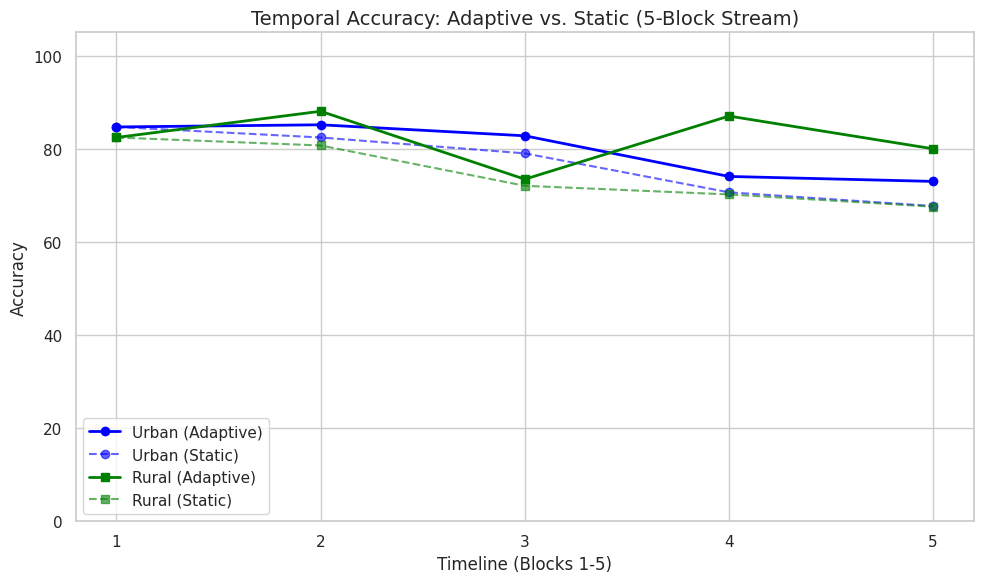

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# ══════════════════════════════════════════════════════════════════════
# 1. TEMPORAL ACCURACY (Internal Blocks 1-5)
# ══════════════════════════════════════════════════════════════════════

def plot_temporal_accuracy(city_ad, city_st, rural_ad, rural_st):
    plt.figure(figsize=(10, 6))
    
    blocks = [r['block'] for r in city_ad]
    
    plt.plot(blocks, [r['mean_species_accuracy'] for r in city_ad], 'o-', label='Urban (Adaptive)', color='blue', linewidth=2)
    plt.plot(blocks, [r['mean_species_accuracy'] for r in city_st], 'o--', label='Urban (Static)', color='blue', alpha=0.6)
    
    plt.plot(blocks, [r['mean_species_accuracy'] for r in rural_ad], 's-', label='Rural (Adaptive)', color='green', linewidth=2)
    plt.plot(blocks, [r['mean_species_accuracy'] for r in rural_st], 's--', label='Rural (Static)', color='green', alpha=0.6)

    plt.title("Temporal Accuracy: Adaptive vs. Static (5-Block Stream)", fontsize=14)
    plt.xlabel("Timeline (Blocks 1-5)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(0, 105)
    plt.xticks(blocks)
    plt.legend()
    plt.tight_layout()
    plt.savefig("plots/urban_rural_self_accuracy.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
plot_temporal_accuracy(city_ad, city_st, rural_ad, rural_st)


In [11]:
# ══════════════════════════════════════════════════════════════════════
# 3. CROSS-DOMAIN: FIT ON FULL SOURCE, ADAPT ON TARGET BLOCKS
# ══════════════════════════════════════════════════════════════════════

def _get_full_source_clf(source_blocks, embeddings, species):
    """
    Fit once on the entire source domain.
    """
    source_idx = np.concatenate([np.asarray(b, dtype=int) for b in source_blocks])

    clf = AdaptiveNCMClassifier()
    clf.fit(embeddings[source_idx], species[source_idx])

    print(
        f"  Full source model | "
        f"Samples: {len(source_idx):,} | "
        f"Species: {len(clf.known_species):,}"
    )
    return clf


def run_transfer_matrix(
    source_blocks,
    target_blocks,
    embeddings,
    species,
    source_label="Source",
    target_label="Target",
    update_model=True,
):
    """
    Cross-domain evaluation with a full-source model.

    Static:
        Fit once on all source samples, then evaluate each target block
        with no target-side updates.

    Adaptive:
        Fit once on all source samples, evaluate target block t,
        then absorb target block t before moving to t+1.
    """
    clf = _get_full_source_clf(source_blocks, embeddings, species)

    print("=" * 75)
    print(
        f"CROSS-DOMAIN: {source_label} -> {target_label} "
        f"({'Adaptive' if update_model else 'Static'})"
    )
    print("=" * 75)

    results = []

    for block_id, tgt_idx in enumerate(target_blocks, start=1):
        tgt_idx = np.asarray(tgt_idx, dtype=int)
        embs_t = embeddings[tgt_idx]
        lbls_t = species[tgt_idx]

        n_known_before = len(clf.known_species)
        metrics = evaluate_block(clf, embs_t, lbls_t)

        if update_model:
            update_classifier_on_block(clf, embs_t, lbls_t)

        n_known_after = len(clf.known_species)

        row = {
            "target_block": block_id,
            **metrics,
            "n_known_before": n_known_before,
            "n_known_after": n_known_after,
            "n_source_samples": int(sum(len(b) for b in source_blocks)),
        }
        results.append(row)

        print(
            f"  Target block {block_id} | "
            f"Acc: {_fmt(metrics['mean_species_accuracy'])} | "
            f"Known: {n_known_before} -> {n_known_after}"
        )

    print("-" * 75)
    return results


def get_scenario_trajectories(adaptive_results, static_results):
    """
    Both inputs are now target-block trajectories, not source-by-target matrices.
    """
    baseline = [m["mean_species_accuracy"] for m in static_results]
    method = [m["mean_species_accuracy"] for m in adaptive_results]
    return baseline, method

city_to_rural_ad = run_transfer_matrix(
    g1_blocks, g2_blocks, embeddings, species, "City", "Rural", True
)
city_to_rural_st = run_transfer_matrix(
    g1_blocks, g2_blocks, embeddings, species, "City", "Rural", False
)

rural_to_city_ad = run_transfer_matrix(
    g2_blocks, g1_blocks, embeddings, species, "Rural", "City", True
)
rural_to_city_st = run_transfer_matrix(
    g2_blocks, g1_blocks, embeddings, species, "Rural", "City", False
)

  Full source model | Samples: 57,359 | Species: 17
CROSS-DOMAIN: City -> Rural (Adaptive)
  Target block 1 | Acc: 65.732 | Known: 17 -> 20
  Target block 2 | Acc: 87.044 | Known: 20 -> 20
  Target block 3 | Acc: 82.163 | Known: 20 -> 21
  Target block 4 | Acc: 87.110 | Known: 21 -> 21
  Target block 5 | Acc: 79.323 | Known: 21 -> 21
---------------------------------------------------------------------------
  Full source model | Samples: 57,359 | Species: 17
CROSS-DOMAIN: City -> Rural (Static)
  Target block 1 | Acc: 65.732 | Known: 17 -> 17
  Target block 2 | Acc: 78.067 | Known: 17 -> 17
  Target block 3 | Acc: 74.842 | Known: 17 -> 17
  Target block 4 | Acc: 81.202 | Known: 17 -> 17
  Target block 5 | Acc: 73.019 | Known: 17 -> 17
---------------------------------------------------------------------------
  Full source model | Samples: 45,736 | Species: 20
CROSS-DOMAIN: Rural -> City (Adaptive)
  Target block 1 | Acc: 74.696 | Known: 20 -> 21
  Target block 2 | Acc: 82.865 | Known

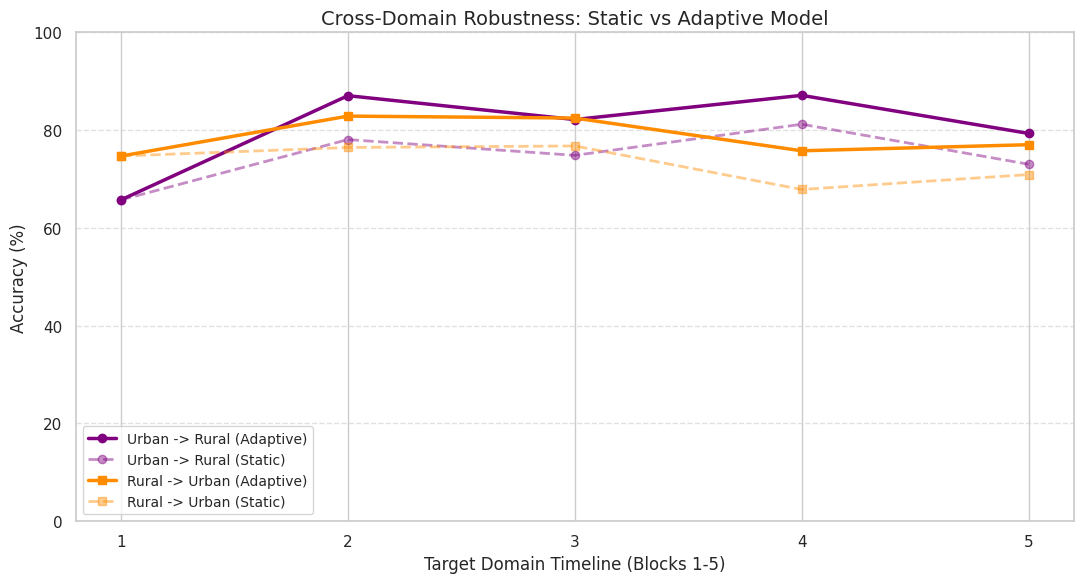

In [ ]:
def plot_cross_domain_evaluation(c_to_r_ad, c_to_r_st, r_to_c_ad, r_to_c_st):
    plt.figure(figsize=(11, 6))

    city_to_rural_adaptive = [m["mean_species_accuracy"] for m in c_to_r_ad]
    city_to_rural_static = [m["mean_species_accuracy"] for m in c_to_r_st]

    rural_to_city_adaptive = [m["mean_species_accuracy"] for m in r_to_c_ad]
    rural_to_city_static = [m["mean_species_accuracy"] for m in r_to_c_st]

    blocks = list(range(1, len(city_to_rural_adaptive) + 1))

    plt.plot(
        blocks,
        city_to_rural_adaptive,
        "o-",
        color="purple",
        linewidth=2.5,
        label="Urban -> Rural (Adaptive)",
    )
    plt.plot(
        blocks,
        city_to_rural_static,
        "o--",
        color="purple",
        alpha=0.45,
        linewidth=2.0,
        label="Urban -> Rural (Static)",
    )

    plt.plot(
        blocks,
        rural_to_city_adaptive,
        "s-",
        color="darkorange",
        linewidth=2.5,
        label="Rural -> Urban (Adaptive)",
    )
    plt.plot(
        blocks,
        rural_to_city_static,
        "s--",
        color="darkorange",
        alpha=0.45,
        linewidth=2.0,
        label="Rural -> Urban (Static)",
    )

    plt.title("Cross-Domain Robustness: Static vs Adaptive Model", fontsize=14)
    plt.xlabel("Target Domain Timeline (Blocks 1-5)", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.ylim(0, 100)
    plt.xticks(blocks)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(loc="lower left", frameon=True, fontsize=10)
    plt.tight_layout()
    plt.savefig("plots/urban_rural_cross_domain.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
plot_cross_domain_evaluation(city_to_rural_ad, city_to_rural_st,
                            rural_to_city_ad, rural_to_city_st)